# Seeded LC vs BCO on Mumford0

This notebook compares LC construction, seeded LC improvement, and BCO variants on `Mumford0` with the same route contract used by the NX-heuristic dataset:

- `N_ROUTES = 10`
- `MIN_ROUTE_LEN = 2`
- `MAX_ROUTE_LEN = 12`

The BCO variants use readable names for the mutation mix, while the low-level BCO API still receives its internal `n_type*` counters.


## 1. Imports


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from torch_geometric.loader import DataLoader

from connectpt.routes_generator.citygraph_dataset import get_dataset_from_config, load_macsa_scenarios
from connectpt.routes_generator.improvement_learning import load_raw_graphs_and_lc_routes, rollout_lc_improvement
from connectpt.routes_generator.utils import get_eval_cfg
from connectpt.routes_generator.eval_route_generator import eval_model
from connectpt.routes_generator.bee_colony import bee_colony
from connectpt.routes_generator.torch_utils import dump_routes, get_batch_tensor_from_routes
from connectpt.routes_generator.transit_time_estimator import RouteGenBatchState
import connectpt.routes_generator.utils as lrnu

# eval_lib -- notebook-support package next to this notebook. It holds the
# helper functions / config builders / runners that used to fill the giant
# "Helper Functions" cell, plus the experiment parameters (eval_lib/params.py)
# and repo paths (eval_lib/context.py). `from eval_lib import *` brings the
# helpers, parameters and paths into the notebook namespace.
import os as _os, sys as _sys
_NB_DIR = _os.path.abspath(".")
if _NB_DIR not in _sys.path:
    _sys.path.insert(0, _NB_DIR)
import eval_lib
from eval_lib import *
from eval_lib import plots as _plots
# _run_baseline is private (underscore -> skipped by import *); the
# NSGA-II comparison calls it directly, so bring it in explicitly.
from eval_lib import _run_baseline

# Print wide DataFrames in full (no column / width truncation).
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


## 2. Paths And Experiment Parameters


In [2]:
# Repo paths and experiment parameters now live in the eval_lib package
# (imported above): paths in eval_lib/context.py, tunable parameters in
# eval_lib/params.py -- edit that file to tune a run. The names are in scope
# here via `from eval_lib import *`.
print(f"ROOT_DIR: {ROOT_DIR}")
print(f"CFG_DIR: {CFG_DIR}")
print(f"MODEL_WEIGHTS_PATH exists: {MODEL_WEIGHTS_PATH.exists()}")
print(f"EDIT_MODEL_WEIGHTS_PATH exists: {EDIT_MODEL_WEIGHTS_PATH.exists()}")


ROOT_DIR: D:\PythonProjects\connectpt
CFG_DIR: D:\PythonProjects\connectpt\connectpt\routes_generator\cfg
MODEL_WEIGHTS_PATH exists: True
EDIT_MODEL_WEIGHTS_PATH exists: True


## 3. Load Benchmark Tensors


In [3]:
# load_benchmark_tensors now lives in eval_lib (imported above). Load the
# default Mumford0 benchmark tensors and register them with
# eval_lib.make_test_dataloader.
input_tensors = load_benchmark_tensors()
set_input_tensors(input_tensors)
print({key: tuple(value.shape) for key, value in input_tensors.items()})


{'node_locs': (30, 2), 'street_adj': (30, 30), 'demand': (30, 30)}


## 5. Baseline LC On Mumford0


In [4]:
base_result = run_lc_base()

cfg_lc_base = base_result["cfg"]
lc_base_run_name = base_result["run_name"]
lc_base_metrics = base_result["metrics"]
lc_base_unserved = base_result["unserved_demand"]
lc_base_routes = base_result["routes"]
lc_base_step_counts = base_result["step_counts"]

print_lc_result(lc_base_run_name, lc_base_metrics, lc_base_routes, lc_base_step_counts)
lc_base_routes


Run name: lc_lc_base_mumford0_10r_len12
cost=0.9837 [d=0.453, r=0.531, c=0.000, pen=0.000]
ATT=23.550, RTT=276.000, MC=17.433, d_un=6.12%
Routes shape: (1, 10, 7)
Step counts: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


tensor([[[ 8, 12,  0, 28, 16, 27, 29],
         [13,  0, 17, 11,  3,  9, -1],
         [23, 14,  7, 16,  6,  5, -1],
         [22, 18,  0, 25,  7, 20, -1],
         [ 4,  7, 10, 15, -1, -1, -1],
         [ 9,  1, 24, -1, -1, -1, -1],
         [21,  2, 29, -1, -1, -1, -1],
         [26,  0, 19, -1, -1, -1, -1],
         [15, 29, -1, -1, -1, -1, -1],
         [24,  4, -1, -1, -1, -1, -1]]])

## 6. Seeded LC Revisit Of All Base Routes With One More Total Route And Larger Max Route Length


In [5]:
seeded_result = run_lc_seeded(lc_base_routes)

cfg_lc_seeded = seeded_result["cfg"]
lc_seeded_run_name = seeded_result["run_name"]
lc_seeded_metrics = seeded_result["metrics"]
lc_seeded_unserved = seeded_result["unserved_demand"]
lc_seeded_routes = seeded_result["routes"]
lc_seeded_step_counts = seeded_result["step_counts"]

print_lc_result(lc_seeded_run_name, lc_seeded_metrics, lc_seeded_routes)
lc_seeded_routes

if RUN_RL_ONLY_BASELINE:
    (
        rl_improvement_run_name,
        rl_improvement_metrics,
        rl_improvement_unserved,
        rl_improvement_routes,
        rl_improvement_cfg,
        *_,
    ) = run_rl_improvement(lc_base_routes)
    print_lc_result(rl_improvement_run_name, rl_improvement_metrics, rl_improvement_routes)
    display(rl_improvement_routes)
else:
    rl_improvement_run_name = None
    rl_improvement_metrics = None
    rl_improvement_unserved = None
    rl_improvement_routes = None
    rl_improvement_cfg = None
    print("Skipping RL improvement only baseline; RUN_RL_ONLY_BASELINE=False")


Run name: lc_lc_seeded_second_pass_mumford0_10r_len12
cost=0.9837 [d=0.453, r=0.531, c=0.000, pen=0.000]
ATT=23.550, RTT=276.000, MC=17.433, d_un=6.12%
Routes shape: (1, 10, 7)
[rl_improvement_only_from_lc_mumford0] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=10 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
Run name: rl_improvement_rl_improvement_only_from_lc_mumford0
cost=0.9837 [d=0.453, r=0.531, c=0.000, pen=0.000]
ATT=23.550, RTT=276.000, MC=17.433, d_un=6.12%
Routes shape: (1, 10, 7)


tensor([[[ 8, 12,  0, 28, 16, 27, 29],
         [13,  0, 17, 11,  3,  9, -1],
         [23, 14,  7, 16,  6,  5, -1],
         [22, 18,  0, 25,  7, 20, -1],
         [ 4,  7, 10, 15, -1, -1, -1],
         [ 9,  1, 24, -1, -1, -1, -1],
         [21,  2, 29, -1, -1, -1, -1],
         [26,  0, 19, -1, -1, -1, -1],
         [15, 29, -1, -1, -1, -1, -1],
         [24,  4, -1, -1, -1, -1, -1]]])

## 7. Seeded BCO Experiments With Uniform Route Selection

Each BCO variant is run once with `uniform random` route-slot selection.


### Experiment Matrix

For uniform route-slot selection, we run:

- seeded heuristic BCO: `heuristic_rebuild + local_endpoint_edit`
- `construction_only`: construction model extend/halt only
- `extend_trim_edit_only`: LC-improvement edit model with extend, trim-start, trim-end, halt
- `trim_then_extend_only`: trim/halt followed by construction extend/halt
- `construction_trim_split_5_5`: construction + trim in a `5+5` bee split
- `construction_trim_split_8_2`: construction + trim in an `8+2` bee split

All neural route-editing variants edit the selected route while the other route slots remain visible as context.

| Variant | Internal BCO mutation | Model used | One mutation can |
|---|---|---|---|
| `seeded_heuristic` | `type1 + type2` | classic BCO heuristics | rebuild selected routes and make random local endpoint edits |
| `construction_only` | `type4` | construction / route-generation model | extend the selected route or halt |
| `extend_trim_edit_only` | `type5` | trim-capable LC-improvement edit model | extend, trim the start, trim the end, or halt |
| `trim_only` | `type6` | trim-capable LC-improvement edit model | trim the start, trim the end, or halt |
| `trim_then_extend_only` | `type7` | edit model + construction model | trim or halt, then extend or halt before scoring |


In [6]:
BCO_VARIANTS = build_default_bco_variants()
BCO_VARIANTS


[{'key': 'seeded_heuristic',
  'summary_label': 'Seeded heuristic BCO (rebuild + local edit)',
  'run_name': 'seeded_bco_heuristic_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 5,
  'n_type2_bees': None,
  'n_type4_bees': 0,
  'n_type5_bees': 0,
  'n_type6_bees': 0,
  'n_type7_bees': 0}]

## 8. Worse Acceptance Seed Sweep

This section compares the same readable BCO variants with soft worse acceptance disabled and enabled. Each variant is run with 10 seeds, then metrics, cost-function terms, and mutation statistics are averaged by variant and acceptance mode.


In [7]:
# Unified worse-accept seed sweep over the Mumford0 LC-init graph: one
# run_seed_sweep covering Initial + RL-only + every BCO variant x
# {without_worse, worse}. worse / without-worse land as separate rows.
LC_GRAPH_SPECS = [{"dataset": "Mumford0 LC init", "init_routes": lc_base_routes}]
WORSE_ACCEPT_METHOD_SPECS = (
    [INITIAL_METHOD]
    + ([RL_ONLY_METHOD] if RUN_RL_ONLY_BASELINE else [])
    + [bco_method(variant) for variant in BCO_VARIANTS]
)
if REUSE_EXISTING_SWEEP_RESULTS and "worse_accept_seed_sweep" in globals():
    print("Reusing existing worse_accept_seed_sweep; set REUSE_EXISTING_SWEEP_RESULTS=False to rerun BCO.")
else:
    worse_accept_seed_sweep = run_seed_sweep(
        LC_GRAPH_SPECS,
        WORSE_ACCEPT_METHOD_SPECS,
        WORSE_ACCEPT_SEEDS,
        accept_modes=("without_worse", "worse"),
        run_name_scope="worse_accept_",
    )
worse_accept_rows_df = worse_accept_seed_sweep["rows_df"]
worse_accept_summary_df = worse_accept_seed_sweep["summary_df"]
worse_accept_results = worse_accept_seed_sweep["results"]


[seed-sweep 1/4] dataset=Mumford0 LC init method=Initial network accept=n/a seed=0
[seed-sweep 2/4] dataset=Mumford0 LC init method=RL improvement only accept=n/a seed=0
[worse_accept_rl_only] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=10 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[seed-sweep 3/4] dataset=Mumford0 LC init method=Seeded heuristic BCO (rebuild + local edit) accept=without_worse seed=0
[worse_accept_seeded_bco_heuristic_from_lc_mumford0_without_worse] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[seed-sweep 4/4] dataset=Mumford0 LC init method=Seeded heuristic BCO (rebuild + local edit) accept=worse seed=0
[worse_accept_seeded_bco_heuristic_from_lc_mumford0_worse] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_

In [ ]:
# Seed-averaged summary for the LC-init worse-accept sweep
# (mean/std per method x accept_mode). Saved to artifacts/results/.
save_table(worse_accept_summary_df, "section8_lc_summary")
display(worse_accept_summary_df.round(4))


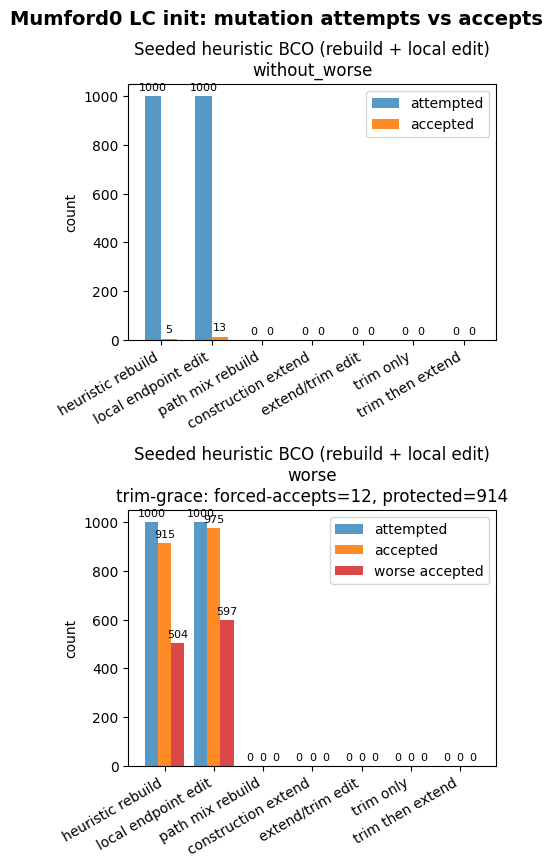

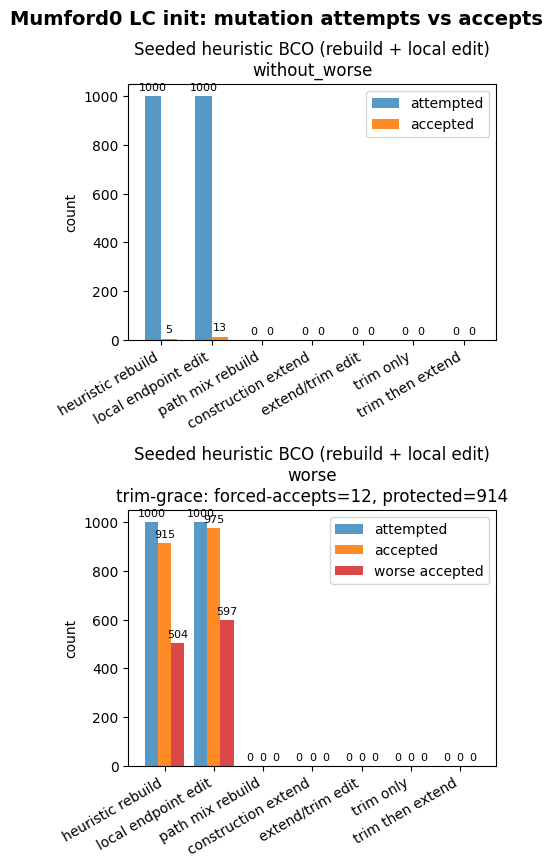

In [9]:
# Unified mutation histogram grid for the LC-init worse-accept seed sweep:
# rows = accept modes, cols = BCO methods; bars are attempted / accepted /
# worse-accepted per mutation type, seed-averaged.
plot_seed_sweep_mutation_grid(worse_accept_seed_sweep, "Mumford0 LC init")


## 8b. NX Heuristic Dataset BCO Seed Sweep

This block repeats the same BCO worse-accept seed sweep on one graph from `examples/nx_heuristic_results_10r_len12`. The main Mumford0/Initial-LC sweep above is left unchanged.


In [10]:
# Dataset graph source for a separate BCO seed sweep on one graph only.
import pickle
import random

from connectpt.routes_generator.citygraph_dataset import STOP_KEY

# Dataset inputs resolve through eval_lib.context (datasets/).
NX_SWEEP_RAW_GRAPHS_PATH = RAW_GRAPHS_PATH
NX_SWEEP_RESULTS_DIR = LC_RESULTS_DIR
NX_SWEEP_GRAPH_INDEX = 0


(
    nx_sweep_graph,
    nx_sweep_initial_routes,
    nx_sweep_route_path,
) = load_single_nx_heuristic_graph_and_routes(
    NX_SWEEP_RAW_GRAPHS_PATH,
    NX_SWEEP_RESULTS_DIR,
    NX_SWEEP_GRAPH_INDEX,
)

nx_sweep_route_lengths = (nx_sweep_initial_routes > -1).sum(dim=-1)
nx_sweep_real_route_lengths = nx_sweep_route_lengths[nx_sweep_route_lengths > 0]
assert nx_sweep_initial_routes.shape == (1, N_ROUTES, MAX_ROUTE_LEN), nx_sweep_initial_routes.shape
assert int(nx_sweep_real_route_lengths.min().item()) == MAX_ROUTE_LEN, nx_sweep_real_route_lengths.tolist()
assert int(nx_sweep_real_route_lengths.max().item()) == MAX_ROUTE_LEN, nx_sweep_real_route_lengths.tolist()
nx_sweep_tensors = nx_graph_to_tensor_dataset(nx_sweep_graph)
print(
    f"NX dataset sweep graph={NX_SWEEP_GRAPH_INDEX}, "
    f"nodes={nx_sweep_graph[STOP_KEY].num_nodes}, "
    f"seed_routes_shape={tuple(nx_sweep_initial_routes.shape)}, route_file={nx_sweep_route_path.name}"
)


NX dataset sweep graph=0, nodes=50, seed_routes_shape=(1, 10, 12), route_file=lc_nx_heuristic_graph_0000_routes_routes.pkl


In [11]:
# Same unified seed sweep on the NX-heuristic dataset graph -- identical
# method matrix (Initial + RL-only + BCO variants x accept modes).
NX_GRAPH_SPECS = [{
    "dataset": f"NX dataset graph {NX_SWEEP_GRAPH_INDEX}",
    "init_routes": nx_sweep_initial_routes,
    "tensors": nx_sweep_tensors,
}]
if REUSE_EXISTING_NX_SWEEP_RESULTS and "nx_dataset_bco_seed_sweep" in globals():
    print("Reusing existing nx_dataset_bco_seed_sweep; set REUSE_EXISTING_NX_SWEEP_RESULTS=False to rerun BCO.")
else:
    nx_dataset_bco_seed_sweep = run_seed_sweep(
        NX_GRAPH_SPECS,
        WORSE_ACCEPT_METHOD_SPECS,
        NX_DATASET_SWEEP_SEEDS,
        accept_modes=("without_worse", "worse"),
        run_name_scope="nx_dataset_",
    )
nx_dataset_bco_rows_df = nx_dataset_bco_seed_sweep["rows_df"]
nx_dataset_bco_summary_df = nx_dataset_bco_seed_sweep["summary_df"]
nx_dataset_bco_results = nx_dataset_bco_seed_sweep["results"]


[seed-sweep 1/4] dataset=NX dataset graph 0 method=Initial network accept=n/a seed=0
[seed-sweep 2/4] dataset=NX dataset graph 0 method=RL improvement only accept=n/a seed=0
[nx_dataset_rl_only] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=10 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


[seed-sweep 3/4] dataset=NX dataset graph 0 method=Seeded heuristic BCO (rebuild + local edit) accept=without_worse seed=0
[nx_dataset_seeded_bco_heuristic_from_lc_mumford0_without_worse] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[seed-sweep 4/4] dataset=NX dataset graph 0 method=Seeded heuristic BCO (rebuild + local edit) accept=worse seed=0
[nx_dataset_seeded_bco_heuristic_from_lc_mumford0_worse] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


In [ ]:
# Seed-averaged summary for the NX-dataset sweep -> artifacts/results/.
save_table(nx_dataset_bco_summary_df, "section8b_nx_summary")
display(nx_dataset_bco_summary_df.round(4))

# Same unified mutation histogram grid as the LC-init sweep, here for the
# NX-heuristic dataset init -- so both inits get the identical view.
plot_seed_sweep_mutation_grid(
    nx_dataset_bco_seed_sweep,
    f"NX dataset graph {NX_SWEEP_GRAPH_INDEX}",
)


## 9. Single-Seed Mutation Type Statistics


In [ ]:
# Section 9 -- table 1/2: Mumford0 LC-init comparison via the shared
# build_comparison_table. One row per method x accept_mode (worse /
# without-worse as separate rows), plus deltas vs the initial network.
lc_comparison_df = build_comparison_table(worse_accept_results)
save_table(lc_comparison_df, "section9_lc_comparison")
display(lc_comparison_df.round(4))


In [ ]:
# Section 9 -- table 2/2: NX-heuristic dataset comparison, same shape as the
# LC table above (same build_comparison_table over the NX seed-sweep results).
nx_comparison_df = build_comparison_table(nx_dataset_bco_results)
save_table(nx_comparison_df, "section9_nx_comparison")
display(nx_comparison_df.round(4))


## 9b. Baseline Optimizers (SA / GA / Hyper-heuristics)

Classic transit-route optimizers ported from the ancestor repository
`AHolliday/transit_learning` — simulated annealing, a genetic algorithm and a
selection hyper-heuristic. All three are purely heuristic (no neural model) and
are run on Mumford0 from the same LC-seeded initial routes as the BCO
experiments above, so the table below is directly comparable with the BCO
`comparison_df`.

In [15]:
# --- run the three baselines on Mumford0 from the LC-seeded routes ---
BASELINE_INIT_ROUTES = lc_base_routes

sa_run_name, sa_metrics, sa_unserved, sa_routes = run_sa(
    build_sa_cfg("sa_mumford0", N_ROUTES, MIN_ROUTE_LEN, MAX_ROUTE_LEN),
    init_routes=BASELINE_INIT_ROUTES)
dump_routes(sa_run_name, sa_routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

ga_run_name, ga_metrics, ga_unserved, ga_routes = run_ga(
    build_ga_cfg("ga_mumford0", N_ROUTES, MIN_ROUTE_LEN, MAX_ROUTE_LEN),
    init_routes=BASELINE_INIT_ROUTES)
dump_routes(ga_run_name, ga_routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

hh_run_name, hh_metrics, hh_unserved, hh_routes = run_hh(
    build_hh_cfg("hh_mumford0", N_ROUTES, MIN_ROUTE_LEN, MAX_ROUTE_LEN),
    init_routes=BASELINE_INIT_ROUTES)
dump_routes(hh_run_name, hh_routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

baseline_rows = [
    {**summarize_run("Initial LC", lc_base_metrics, lc_base_routes),
     "optimizer": "Initial LC"},
    {**summarize_run("Simulated annealing", sa_metrics, sa_routes),
     "optimizer": "Simulated annealing"},
    {**summarize_run("Genetic algorithm", ga_metrics, ga_routes),
     "optimizer": "Genetic algorithm"},
    {**summarize_run("Hyper-heuristics", hh_metrics, hh_routes),
     "optimizer": "Hyper-heuristics"},
]
baseline_comparison_df = pd.DataFrame(baseline_rows)
_baseline_initial_row = baseline_comparison_df.loc[
    baseline_comparison_df["method"] == "Initial LC"].iloc[0]
baseline_comparison_df["delta_cost_vs_initial_lc"] = (
    baseline_comparison_df["cost"] - _baseline_initial_row["cost"])
baseline_comparison_df["delta_ATT_vs_initial_lc"] = (
    baseline_comparison_df["ATT"] - _baseline_initial_row["ATT"])
baseline_comparison_df["delta_RTT_vs_initial_lc"] = (
    baseline_comparison_df["RTT"] - _baseline_initial_row["RTT"])
baseline_comparison_df = baseline_comparison_df[_plots.filter_component_columns([
    "method",
    "optimizer",
    "cost",
    "cost_demand_term",
    "cost_route_term",
    "cost_connectivity_term",
    "cost_penalty_term",
    "ATT",
    "RTT",
    "median_connectivity",
    "$d_{un}$",
    "# disconnected node pairs",
    "# stops out of bounds",
    "# routes",
    "delta_cost_vs_initial_lc",
    "delta_ATT_vs_initial_lc",
    "delta_RTT_vs_initial_lc",
], ENABLED_COST_COMPONENTS)]

display(baseline_comparison_df.round(4))


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


,method,optimizer,cost,cost_demand_term,cost_route_term,cost_penalty_term,ATT,RTT,$d_{un}$,# stops out of bounds,# routes,delta_cost_vs_initial_lc,delta_ATT_vs_initial_lc,delta_RTT_vs_initial_lc
0,Initial LC,Initial LC,0.9837,0.4529,0.5308,0.0,23.5499,276.0,6.1199,0.0,10,0.0000,0.0000,0.0
1,Simulated annealing,Simulated annealing,0.7443,0.2834,0.3655,0.0,22.3285,288.0,4.1793,0.0,10,-0.2393,-1.2214,12.0
2,Genetic algorithm,Genetic algorithm,0.7019,0.2907,0.3122,0.0,22.9056,246.0,7.9992,0.0,10,-0.2818,-0.6443,-30.0
3,Hyper-heuristics,Hyper-heuristics,0.7240,0.2844,0.3402,0.0,22.4097,268.0,4.3313,0.0,10,-0.2597,-1.1402,-8.0


## 9c. NSGA-II Multi-Objective Comparison

NSGA-II (ported from `AHolliday/transit_learning`) is a multi-objective
optimizer: it does not fit the single-solution `test_method` contract used by
SA / GA / hyper-heuristics, but instead returns a **Pareto front** trading off
mean demand time against total route time.

It is run here in the pure-heuristic Husselmann configuration (no neural
models). To place it in the comparison table the Pareto front is reduced to one
solution — the member with the lowest weighted-sum cost under the table's
objective weights — and that solution is then evaluated with the same
`MyCostModule` the other rows use.

100%|██████████| 160/160 [00:04<00:00, 34.00it/s]
 99%|█████████▉| 39.71/40[00:04<00:00]d:\PythonProjects\connectpt\.venv\Lib\site-packages\tqdm\std.py:636: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
100%|██████████| 40.00/40[00:05<-00:00]
100%|██████████| 30/30 [00:07<00:00,  3.99it/s]

[nsgaii_nsgaii_mumford0] Pareto front members: 40



D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


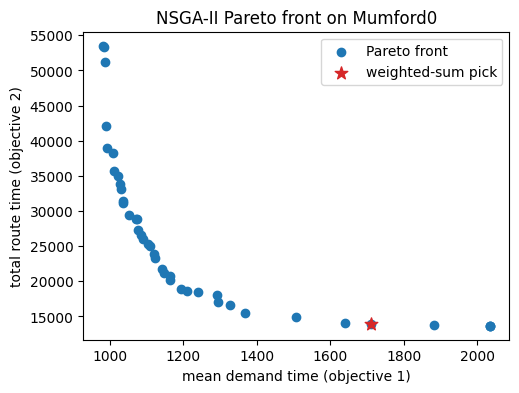

,method,optimizer,cost,cost_demand_term,cost_route_term,cost_penalty_term,ATT,RTT,$d_{un}$,# stops out of bounds,# routes,delta_cost_vs_initial_lc,delta_ATT_vs_initial_lc,delta_RTT_vs_initial_lc
0,Initial LC,Initial LC,0.9837,0.4529,0.5308,0.0,23.5499,276.0,6.1199,0.0,10,0.0000,0.0000,0.0
1,NSGA-II (weighted-sum pick),NSGA-II,0.7529,0.3448,0.2995,0.0,27.1663,236.0,11.7577,0.0,10,-0.2308,3.6164,-40.0


In [16]:
# --- run NSGA-II on Mumford0 ---
nsgaii_run_name, nsgaii_output = run_nsgaii(
    build_nsgaii_cfg("nsgaii_mumford0", N_ROUTES, MIN_ROUTE_LEN, MAX_ROUTE_LEN))
nsgaii_front = nsgaii_output["pareto_pop"]
print(f"[{nsgaii_run_name}] Pareto front members: {len(nsgaii_front)}")

# reduce the front to one solution and evaluate it with the shared MyCostModule
# (build_sa_cfg gives a mumford0 + 'mine'-cost config; test_method with
# method_fn=None just evaluates the supplied routes), so the row is directly
# comparable with the SA/GA/HH/BCO rows above.
nsgaii_best = reduce_pareto_front(
    nsgaii_output, DEMAND_TIME_WEIGHT, ROUTE_TIME_WEIGHT)
nsgaii_routes = nsgaii_best["routes"]
if nsgaii_routes.ndim == 2:
    nsgaii_routes = nsgaii_routes[None]
nsgaii_eval_name, nsgaii_metrics, nsgaii_unserved, nsgaii_routes = _run_baseline(
    None,
    build_sa_cfg("nsgaii_mumford0_eval", N_ROUTES, MIN_ROUTE_LEN, MAX_ROUTE_LEN),
    nsgaii_routes, "nsgaii_eval_", {})
dump_routes(nsgaii_run_name, nsgaii_routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

# Pareto-front scatter, with the weighted-sum pick highlighted
_front_costs = np.array([m["cost"] for m in nsgaii_front], dtype=float)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(_front_costs[:, 0], _front_costs[:, 1], c="tab:blue",
           label="Pareto front")
ax.scatter([float(nsgaii_best["cost"][0])], [float(nsgaii_best["cost"][1])],
           c="tab:red", s=90, marker="*", zorder=3, label="weighted-sum pick")
ax.set_xlabel("mean demand time (objective 1)")
ax.set_ylabel("total route time (objective 2)")
ax.set_title("NSGA-II Pareto front on Mumford0")
ax.legend()
plt.show()

nsgaii_rows = [
    {**summarize_run("Initial LC", lc_base_metrics, lc_base_routes),
     "optimizer": "Initial LC"},
    {**summarize_run("NSGA-II (weighted-sum pick)", nsgaii_metrics, nsgaii_routes),
     "optimizer": "NSGA-II"},
]
nsgaii_comparison_df = pd.DataFrame(nsgaii_rows)
_nsgaii_initial_row = nsgaii_comparison_df.loc[
    nsgaii_comparison_df["method"] == "Initial LC"].iloc[0]
nsgaii_comparison_df["delta_cost_vs_initial_lc"] = (
    nsgaii_comparison_df["cost"] - _nsgaii_initial_row["cost"])
nsgaii_comparison_df["delta_ATT_vs_initial_lc"] = (
    nsgaii_comparison_df["ATT"] - _nsgaii_initial_row["ATT"])
nsgaii_comparison_df["delta_RTT_vs_initial_lc"] = (
    nsgaii_comparison_df["RTT"] - _nsgaii_initial_row["RTT"])
nsgaii_comparison_df = nsgaii_comparison_df[_plots.filter_component_columns([
    "method",
    "optimizer",
    "cost",
    "cost_demand_term",
    "cost_route_term",
    "cost_connectivity_term",
    "cost_penalty_term",
    "ATT",
    "RTT",
    "median_connectivity",
    "$d_{un}$",
    "# disconnected node pairs",
    "# stops out of bounds",
    "# routes",
    "delta_cost_vs_initial_lc",
    "delta_ATT_vs_initial_lc",
    "delta_RTT_vs_initial_lc",
], ENABLED_COST_COMPONENTS)]

display(nsgaii_comparison_df.round(4))


## 10. Route Change Visualization

The initial LC solution is used as the reference. Figures are generated separately for `without_worse` and `with_worse`; each title includes both absolute metrics and the weighted cost terms used in the summed objective.


In [ ]:
# Section 10 -- route-change visualization for the Mumford0 LC-init sweep,
# drawn with the shared render_route_comparison_figure: cell 0 = initial
# network, cells 1.. = RL-only + every BCO variant for one accept mode. The
# route *data* is saved (save_as=...), not the image, so each figure can be
# regenerated later with redraw_route_results.
coords = input_tensors["node_locs"]
street_adj = input_tensors["street_adj"]
reference_run = next(r for r in worse_accept_results if r.kind == "initial")
for accept_mode in ("without_worse", "worse"):
    cases = [
        r for r in worse_accept_results
        if r.kind == "rl_only"
        or (r.kind == "bco" and r.accept_mode == accept_mode)
    ]
    render_route_comparison_figure(
        reference_run,
        cases,
        coords,
        street_adj,
        title=f"Mumford0 route comparison | accept={accept_mode}",
        ncols=1 + len(cases),
        palette="tab10",
        with_overlap_curves=False,
        save_as=f"section10_lc_routes_{accept_mode}",
    )
    plt.show()


In [ ]:
# Section 10 -- route-change visualization on the NX-heuristic dataset graph,
# drawn with the same render_route_comparison_figure as the Mumford0 cell.
# Reuses the NX seed-sweep results from section 8b.
import random

DATASET_TEST_SEED = int(NX_DATASET_SWEEP_SEEDS[0]) if NX_DATASET_SWEEP_SEEDS else 0
random.seed(DATASET_TEST_SEED)
np.random.seed(DATASET_TEST_SEED)
torch.manual_seed(DATASET_TEST_SEED)

# dataset_test_* kept for the objective-weight comparison cell below.
dataset_test_graph = nx_sweep_graph
dataset_test_tensors = nx_sweep_tensors
dataset_test_initial_routes = nx_sweep_initial_routes

nx_coords = nx_sweep_tensors["node_locs"]
nx_street_adj = nx_sweep_tensors["street_adj"]
nx_reference_run = next(r for r in nx_dataset_bco_results if r.kind == "initial")
for accept_mode in ("without_worse", "worse"):
    cases = [
        r for r in nx_dataset_bco_results
        if r.kind == "rl_only"
        or (r.kind == "bco" and r.accept_mode == accept_mode)
    ]
    render_route_comparison_figure(
        nx_reference_run,
        cases,
        nx_coords,
        nx_street_adj,
        title=f"NX dataset graph {NX_SWEEP_GRAPH_INDEX} | accept={accept_mode}",
        ncols=1 + len(cases),
        palette="tab10",
        with_overlap_curves=False,
        save_as=f"section10_nx_routes_{accept_mode}",
    )
    plt.show()

# NX-heuristic comparison table (same build_comparison_table as section 9).
nx_heuristic_comparison_df = build_comparison_table(nx_dataset_bco_results)
save_table(nx_heuristic_comparison_df, "section10_nx_heuristic_comparison")
display(nx_heuristic_comparison_df.round(4))


In [ ]:
# Objective-weight comparison on one NX-heuristic dataset graph.
# For each (demand, route, connectivity) cost-weight combination we score the
# initial NX-heuristic routes, run the seeded-heuristic BCO variant, and run
# RL-improvement-only -- all on the same graph (dataset_test_* from the cell
# above). Each combo gets a comparison-table row and a route figure.
from IPython.display import display

NX_WEIGHT_COMBOS = [
    ("balanced(0.33/0.33/0.33)", 0.33, 0.33, 0.33),
    ("demand-only(1/0/0)", 1.0, 0.0, 0.0),
    ("route-only(0/1/0)", 0.0, 1.0, 0.0),
    ("connectivity-only(0/0/1)", 0.0, 0.0, 1.0),
]
# Drop combos whose weight falls entirely on disabled cost components.
NX_WEIGHT_COMBOS = [
    combo for combo in NX_WEIGHT_COMBOS
    if any(w > 0 for w, name in zip(combo[1:], ("demand", "route", "connectivity"))
           if name in ENABLED_COST_COMPONENTS)
]
nx_weight_variant = next(
    variant for variant in BCO_VARIANTS if variant["key"] == "seeded_heuristic")

nx_weight_rows = []
for combo_label, w_demand, w_route, w_conn in NX_WEIGHT_COMBOS:
    print(f"--- objective weights: {combo_label} ---")
    weights = {"demand_time_weight": w_demand, "route_time_weight": w_route,
               "median_connectivity_weight": w_conn}

    # Initial NX-heuristic routes scored under these cost weights.
    initial_eval_cfg = build_lc_cfg(
        run_name=f"nx_weight_initial_{combo_label}",
        n_routes=N_ROUTES, min_route_len=MIN_ROUTE_LEN,
        max_route_len=MAX_ROUTE_LEN, **weights)
    _, nx_weight_initial_metrics, _, _ = evaluate_routes_on_tensors(
        initial_eval_cfg, dataset_test_tensors, dataset_test_initial_routes)
    nx_weight_rows.append({
        **summarize_run("Initial NX-heuristic",
                        nx_weight_initial_metrics, dataset_test_initial_routes),
        "weights": combo_label})

    # Seeded-heuristic BCO (rebuild + local edit) under these weights.
    nx_weight_bco_cfg = build_bco_cfg(
        run_name=route_selection_run_name(
            f"nx_weight_{nx_weight_variant['run_name']}_{combo_label}", "uniform"),
        n_routes=N_ROUTES, min_route_len=MIN_ROUTE_LEN, max_route_len=MAX_ROUTE_LEN,
        use_neural_bees=nx_weight_variant["use_neural_bees"],
        n_type1_bees=nx_weight_variant["n_type1_bees"],
        n_type2_bees=nx_weight_variant["n_type2_bees"],
        n_type4_bees=nx_weight_variant["n_type4_bees"],
        n_type5_bees=nx_weight_variant.get("n_type5_bees", 0),
        n_type6_bees=nx_weight_variant.get("n_type6_bees", 0),
        n_type7_bees=nx_weight_variant.get("n_type7_bees", 0),
        **weights)
    nx_weight_bco_cfg.experiment.seed = DATASET_TEST_SEED
    nx_weight_bco_mc = {}
    (_, nx_weight_bco_metrics, _, nx_weight_bco_routes, nx_weight_bco_mc) = run_bco(
        nx_weight_bco_cfg, dataset_test_initial_routes,
        mutation_counts_out=nx_weight_bco_mc, tensors=dataset_test_tensors,
        run_name_scope="nx_weight_")
    nx_weight_rows.append({
        **summarize_run(nx_weight_variant["summary_label"],
                        nx_weight_bco_metrics, nx_weight_bco_routes),
        "weights": combo_label})

    combo_cases = [RunResult(
        label=nx_weight_variant["summary_label"], kind="bco",
        metrics=nx_weight_bco_metrics, routes=nx_weight_bco_routes)]

    if RUN_RL_ONLY_BASELINE:
        # RL improvement only under these weights.
        (_, nx_weight_rl_metrics, _, nx_weight_rl_routes, *_) = run_rl_improvement(
            dataset_test_initial_routes, run_name=f"nx_weight_rl_{combo_label}",
            tensors=dataset_test_tensors, weights=weights)
        nx_weight_rows.append({
            **summarize_run("RL improvement only",
                            nx_weight_rl_metrics, nx_weight_rl_routes),
            "weights": combo_label})
        combo_cases.append(RunResult(
            label="RL improvement only", kind="rl_only",
            metrics=nx_weight_rl_metrics, routes=nx_weight_rl_routes))

    # Route figure for this weight combo: initial network vs BCO (+ RL).
    render_route_comparison_figure(
        RunResult(label="Initial NX-heuristic", kind="initial",
                  metrics=nx_weight_initial_metrics,
                  routes=dataset_test_initial_routes),
        combo_cases,
        dataset_test_tensors["node_locs"], dataset_test_tensors["street_adj"],
        title=f"NX-heuristic objective-weight comparison | {combo_label}",
        ncols=1 + len(combo_cases), palette="tab10", with_overlap_curves=False,
        save_as=f"section10_objweight_{combo_label}")
    plt.show()

nx_weight_df = pd.DataFrame(nx_weight_rows)
nx_weight_df = nx_weight_df[_plots.filter_component_columns([
    "weights", "method", "cost", "cost_demand_term", "cost_route_term",
    "cost_connectivity_term", "cost_penalty_term", "ATT", "RTT",
    "median_connectivity", "$d_{un}$", "# disconnected node pairs",
    "# stops out of bounds", "# routes",
], ENABLED_COST_COMPONENTS)]
save_table(nx_weight_df, "section10_objective_weight")
display(nx_weight_df.round(4))


## 11. MACSA Seeded BCO/RL Comparison

Loads every scenario folder under `examples/data/MACSA_data` (for example `mandl_8`), evaluates the supplied one-directional routes, runs RL improvement, runs every BCO variant, and prints scenario-level plus overall comparison tables.

In [ ]:
macsa_scenarios = load_macsa_scenarios(MACSA_DATA_DIR)
print(
    "Loaded MACSA scenarios:",
    [
        (scenario["name"], tuple(scenario["tensors"]["node_locs"].shape), tuple(scenario["routes"].shape))
        for scenario in macsa_scenarios
    ],
)

# Section 11 -- MACSA seeded comparison through the unified run_seed_sweep:
# one graph spec per MACSA scenario, Initial + RL-only + every BCO variant x
# accept mode (per-scenario eval bounds from macsa_eval_bounds).
MACSA_GRAPH_SPECS = []
for scenario in macsa_scenarios:
    n_routes, min_route_len, max_route_len = macsa_eval_bounds(scenario)
    MACSA_GRAPH_SPECS.append({
        "dataset": scenario["name"],
        "init_routes": scenario["routes"],
        "tensors": scenario["tensors"],
        "n_routes": n_routes,
        "min_route_len": min_route_len,
        "max_route_len": max_route_len,
    })

if REUSE_EXISTING_MACSA_COMPARISON and "macsa_seeded_comparison" in globals():
    print("Reusing existing macsa_seeded_comparison; set REUSE_EXISTING_MACSA_COMPARISON=False to rerun BCO.")
else:
    macsa_seeded_comparison = run_seed_sweep(
        MACSA_GRAPH_SPECS,
        WORSE_ACCEPT_METHOD_SPECS,
        MACSA_SEEDS,
        accept_modes=("without_worse", "worse"),
        run_name_scope="macsa_",
    )
macsa_rows_df = macsa_seeded_comparison["rows_df"]
macsa_summary_df = macsa_seeded_comparison["summary_df"]
macsa_results = macsa_seeded_comparison["results"]

# Same unified comparison table + seed-averaged summary as sections 9/10,
# both saved to artifacts/results/.
macsa_comparison_df = build_comparison_table(macsa_results)
save_table(macsa_comparison_df, "section11_macsa_comparison")
save_table(macsa_summary_df, "section11_macsa_summary")
display(macsa_comparison_df.round(4))
display(macsa_summary_df.round(4))

# Route-change figures per MACSA scenario -- shared render_route_comparison_figure
# (cell 0 = initial network, cells 1.. = RL-only + BCO variants for one mode).
for scenario in macsa_scenarios:
    name = scenario["name"]
    scenario_results = [r for r in macsa_results if r.dataset == name]
    if not scenario_results:
        continue
    reference = next((r for r in scenario_results if r.kind == "initial"),
                     scenario_results[0])
    for accept_mode in ("without_worse", "worse"):
        cases = [r for r in scenario_results
                 if r.kind == "rl_only"
                 or (r.kind == "bco" and r.accept_mode == accept_mode)]
        render_route_comparison_figure(
            reference, cases,
            scenario["tensors"]["node_locs"], scenario["tensors"]["street_adj"],
            title=f"MACSA {name} | accept={accept_mode}",
            ncols=1 + len(cases), palette="tab10", with_overlap_curves=False,
            save_as=f"section11_macsa_{name}_{accept_mode}")
        plt.show()


## 12. Benchmark Sweep (Mandl + Mumford0-3)

For each standard benchmark graph an initial route set is built with the
**NX-heuristic** constructor (`build_nx_heuristic_routes`), then every optimizer
is run from that init:

| Benchmark | routes | min len | max len |
|---|---|---|---|
| Mandl    | 6  | 2  | 8  |
| Mumford0 | 12 | 2  | 15 |
| Mumford1 | 15 | 10 | 30 |
| Mumford2 | 56 | 10 | 22 |
| Mumford3 | 60 | 12 | 25 |

Methods: BCO variants, RL-improvement-only, simulated annealing, genetic
algorithm, hyper-heuristics and NSGA-II. The table reports only
**Cp (ATT) | Co (RTT) | d0 | d1 | d2 | d_un | cost**

NSGA-II is multi-objective and builds its own population (Husselmann init), so
it ignores the NX-heuristic routes; its Pareto front is reduced to the
weighted-sum-best member. NSGA-II on Mumford2/3 is slow — set
`BENCHMARK_RUN_NSGAII = False` to skip it.

In [ ]:
if REUSE_EXISTING_BENCHMARK_SWEEP and "benchmark_sweep" in globals():
    print("Reusing existing benchmark_sweep; "
          "set REUSE_EXISTING_BENCHMARK_SWEEP=False to rerun.")
else:
    benchmark_sweep = run_benchmark_sweep()
benchmark_sweep_df = benchmark_sweep["rows_df"]

_benchmark_cols = ["benchmark", "method"] + list(BENCHMARK_METRIC_KEYS.keys())
save_table(benchmark_sweep_df, "section12_benchmark")
display(benchmark_sweep_df[_benchmark_cols].round(4))

# quick cross-benchmark cost view (benchmarks as rows, methods as columns)
benchmark_cost_pivot = benchmark_sweep_df.pivot_table(
    index="benchmark", columns="method", values="cost", aggfunc="mean", sort=False)
display(benchmark_cost_pivot.round(4))

# Route-comparison figures per benchmark city: cell 0 = NX-heuristic initial,
# cells 1.. = each optimizer's routes (shared render_route_comparison_figure;
# route data saved via save_as so the figures can be regenerated).
for spec in benchmark_sweep["specs"]:
    city = spec["city"]
    city_methods = [(m, r) for (c, m), r in benchmark_sweep["routes"].items()
                    if c == city]
    if not city_methods:
        continue
    city_tensors = load_benchmark_tensors(city)
    city_metrics = benchmark_sweep["metrics"]
    ref = next(((m, r) for m, r in city_methods if "initial" in m.lower()),
               city_methods[0])
    reference = RunResult(
        label=f"{city}: {ref[0]}", kind="initial", dataset=city,
        routes=ref[1], metrics=city_metrics.get((city, ref[0]), {}))
    cases = [RunResult(label=m, kind="bco", dataset=city, routes=r,
                       metrics=city_metrics.get((city, m), {}))
             for m, r in city_methods if m != ref[0]]
    render_route_comparison_figure(
        reference, cases,
        city_tensors["node_locs"], city_tensors["street_adj"],
        title=f"{city} benchmark -- route comparison",
        ncols=4, palette="tab10", with_overlap_curves=False,
        save_as=f"section12_benchmark_{city}")
    plt.show()


## 13. Standalone Mumford3 Run (Memory Profiling)

Self-contained cell: re-run **it alone in a fresh kernel** to watch memory behaviour on the largest Mumford instance, without running the rest of the notebook.

In [ ]:
# === Standalone Mumford3 benchmark run -- memory profiling ===
# Self-contained: re-run THIS CELL ALONE in a fresh kernel to observe memory
# behaviour on the largest Mumford instance, without running the rest of the
# notebook. Runs the full benchmark sweep (NX-init + BCO variants + RL + SA +
# GA + HH + NSGA-II) on Mumford3 only.
import gc
import os as _os
import sys as _sys

_NB_DIR = _os.path.abspath(".")
if _NB_DIR not in _sys.path:
    _sys.path.insert(0, _NB_DIR)
import torch
import eval_lib
from eval_lib import *
from IPython.display import display

MUMFORD3_SPEC = {"city": "Mumford3", "n_routes": 60,
                 "min_route_len": 12, "max_route_len": 25}

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

mumford3_sweep = run_benchmark_sweep(specs=[MUMFORD3_SPEC])
mumford3_sweep_df = mumford3_sweep["rows_df"]

if torch.cuda.is_available():
    print(f"peak CUDA memory: "
          f"{torch.cuda.max_memory_allocated() / 1e9:.2f} GB allocated, "
          f"{torch.cuda.max_memory_reserved() / 1e9:.2f} GB reserved")

display(mumford3_sweep_df[["benchmark", "method"]
                          + list(BENCHMARK_METRIC_KEYS.keys())].round(4))
